<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [3]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [4]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-4-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [5]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [6]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [7]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


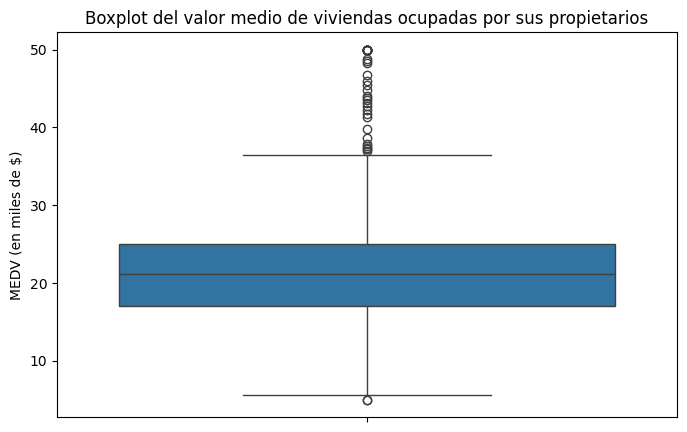

In [9]:
# "Valor medio de las viviendas ocupadas por sus propietarios"
pyplot.figure(figsize=(8, 5))
sns.boxplot(data=boston_df, y='MEDV')
pyplot.title('Boxplot del valor medio de viviendas ocupadas por sus propietarios')
pyplot.ylabel('MEDV (en miles de $)')
pyplot.show()

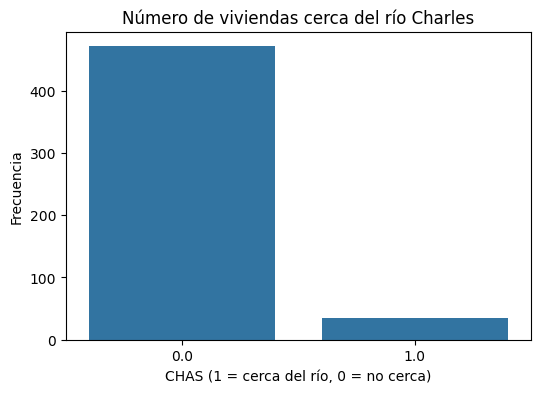

In [10]:
# Proporcione un diagrama de barras para la variable "río Charles"

pyplot.figure(figsize=(6, 4))
sns.countplot(data=boston_df, x='CHAS')
pyplot.title('Número de viviendas cerca del río Charles')
pyplot.xlabel('CHAS (1 = cerca del río, 0 = no cerca)')
pyplot.ylabel('Frecuencia')
pyplot.show()

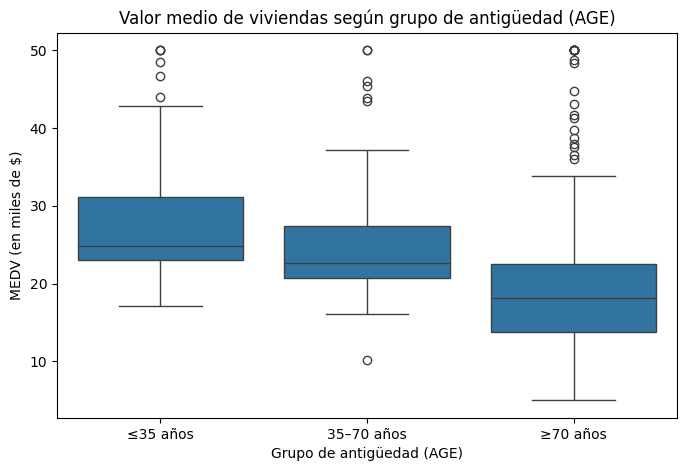

In [13]:
#Proporcione un boxplot para la variable MEDV frente a la variable EDAD. (Discretice la variable edad en tres grupos de 35 años o menos, entre 35 y 70 años y 70 años o más)

# Agrupar AGE en 3 categorías
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'], bins=[0, 35, 70, 100], labels=['≤35 años', '35–70 años', '≥70 años'])

pyplot.figure(figsize=(8, 5))
sns.boxplot(data=boston_df, x='AGE_GROUP', y='MEDV')
pyplot.title('Valor medio de viviendas según grupo de antigüedad (AGE)')
pyplot.xlabel('Grupo de antigüedad (AGE)')
pyplot.ylabel('MEDV (en miles de $)')
pyplot.show()

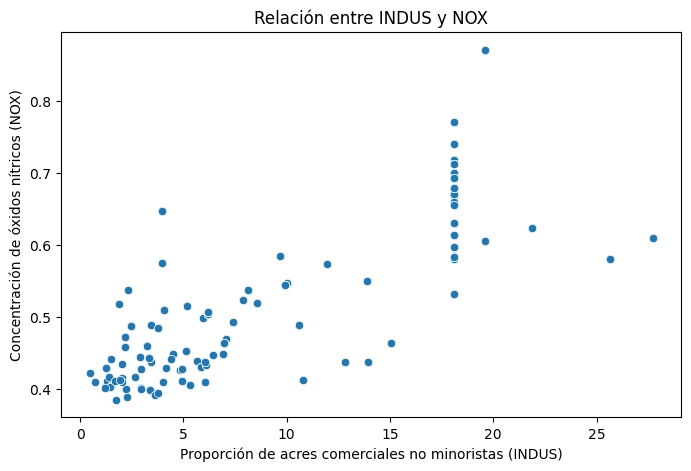

In [14]:
#Proporcione un diagrama de dispersión para mostrar la relación entre las concentraciones de óxido nítrico y la proporción de acres comerciales no minoristas por ciudad. 
#¿Qué puede decir sobre la relación?

pyplot.figure(figsize=(8, 5))
sns.scatterplot(data=boston_df, x='INDUS', y='NOX')
pyplot.title('Relación entre INDUS y NOX')
pyplot.xlabel('Proporción de acres comerciales no minoristas (INDUS)')
pyplot.ylabel('Concentración de óxidos nítricos (NOX)')
pyplot.show()

In [15]:
#Relación positiva, es decir, a mayor proporción de zonas industriales, mayor concentración de NOX.

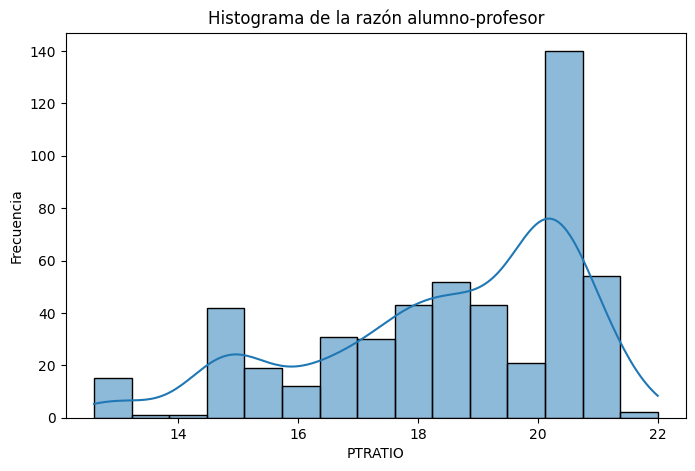

In [17]:
# Cree un histograma para la variable proporción de alumnos por profesor
pyplot.figure(figsize=(8, 5))
sns.histplot(data=boston_df, x='PTRATIO', bins=15, kde=True)
pyplot.title('Histograma de la razón alumno-profesor')
pyplot.xlabel('PTRATIO')
pyplot.ylabel('Frecuencia')
pyplot.show()

In [22]:
# 1. ¿Existe una diferencia significativa en el valor medio de las casas delimitadas por el río Charles o no? (Prueba T para muestras independientes)
#Hipótesis:
# H₀: Las medias de MEDV son iguales entre los grupos CHAS = 1 y CHAS = 0
# H₁: Las medias son diferentes.

medv_chas1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
medv_chas0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

t_stat, p_val = scipy.stats.ttest_ind(medv_chas1, medv_chas0)
print("T-test resultado:")
print(f"T = {t_stat:.4f}, p = {p_val:.4f}")


T-test resultado:
T = 3.9964, p = 0.0001


In [20]:
# Si p < 0.05, se rechaza H₀ → hay diferencia significativa.

In [24]:
# 2. ¿Existe alguna diferencia en los valores medios de las casas (MEDV) para cada proporción de unidades ocupadas por sus propietarios construidas antes de 1940 (AGE)? (ANOVA)
# Hipótesis:
# H₀: Las medias de MEDV son iguales entre grupos de edad.
# H₁: Al menos una media es diferente.

modelo = ols('MEDV ~ C(AGE_GROUP)', data=boston_df).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print(anova_table)


                    sum_sq     df         F        PR(>F)
C(AGE_GROUP)   5401.731883    2.0  36.40765  1.710501e-15
Residual      37314.563532  503.0       NaN           NaN


In [25]:
# hay diferencias significativas entre los grupos.

In [26]:
# 3. ¿Podemos concluir que no existe relación entre las concentraciones de óxido nítrico y la proporción de acres comerciales no minoristas por ciudad? (Correlación de Pearson)
#  Hipótesis:
# H₀: No hay correlación entre NOX e INDUS (r = 0)
# H₁: Existe correlación (r ≠ 0)

corr, p_val = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print(f"Coeficiente de correlación r = {corr:.4f}, p = {p_val:.4f}")

Coeficiente de correlación r = 0.7637, p = 0.0000


In [27]:
# No hay correlación entre NOX e INDUS

In [30]:
# 4.¿Cuál es el impacto de una distancia ponderada adicional a los cinco centros de empleo de Boston sobre el valor medio de las viviendas ocupadas por sus propietarios? (Análisis de regresión)
#  Hipótesis:
# H₀: El coeficiente de DIS es 0 (no hay impacto)
# H₁: El coeficiente de DIS ≠ 0 (hay impacto significativo)

X = sm.add_constant(boston_df['DIS'])  # añade intercepto β₀
y = boston_df['MEDV']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 14 Jul 2025   Prob (F-statistic):           1.21e-08
Time:                        23:07:52   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

In [31]:
# DIS tiene un impacto significativo sobre MEDV